In [1]:
import torch

In [2]:
from torchvision import datasets
from torchvision.transforms import ToTensor
train_data = datasets.MNIST(
    root='data',
    train=True,
    transform=ToTensor(),
    download=True,
)
test_data = datasets.MNIST(
    root='data',
    train=False,
    transform=ToTensor(),
)

In [ ]:
print(train_data)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()


In [ ]:
print(test_data)

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [ ]:
print(test_data.data.size())

torch.Size([10000, 28, 28])


In [ ]:
print(train_data.data.size())

torch.Size([60000, 28, 28])


0.9411765


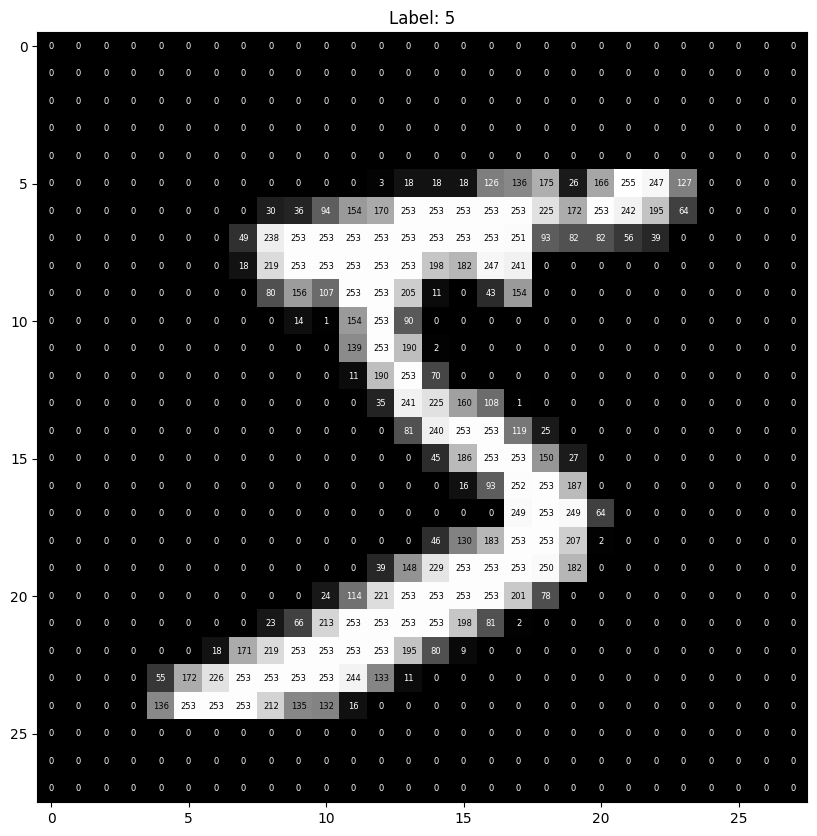

In [3]:
import matplotlib.pyplot as plt

# 1. 데이터와 라벨을 분리해서 가져옵니다.
img, label = train_data[0] 

# 만약 img가 PyTorch 텐서라면 넘파이 배열로 변환합니다.
img_n = img.numpy().squeeze() # squeeze는 (1, 28, 28)을 (28, 28)로 만듭니다.

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(img_n, cmap='gray')
print(img_n[14,14])
# 2. 반복문에서 img_n(2차원 배열)을 참조합니다.
for i in range(img_n.shape[0]):    # 행 (y)
    for j in range(img_n.shape[1]): # 열 (x)
        val = int(img_n[i, j]*255)
        # 배경색에 따라 글자색 결정 (어두우면 흰색, 밝으면 검은색)
        c = 1 if val < 128 else 0
        # 좌표는 (x, y) 순서이므로 (j, i)를 입력합니다.
        ax.text(j, i, str(val), color=(c, c, c), 
                ha='center', va='center', fontsize=6)

plt.title(f'Label: {label}') # f-string 사용이 더 간편합니다.
plt.show()

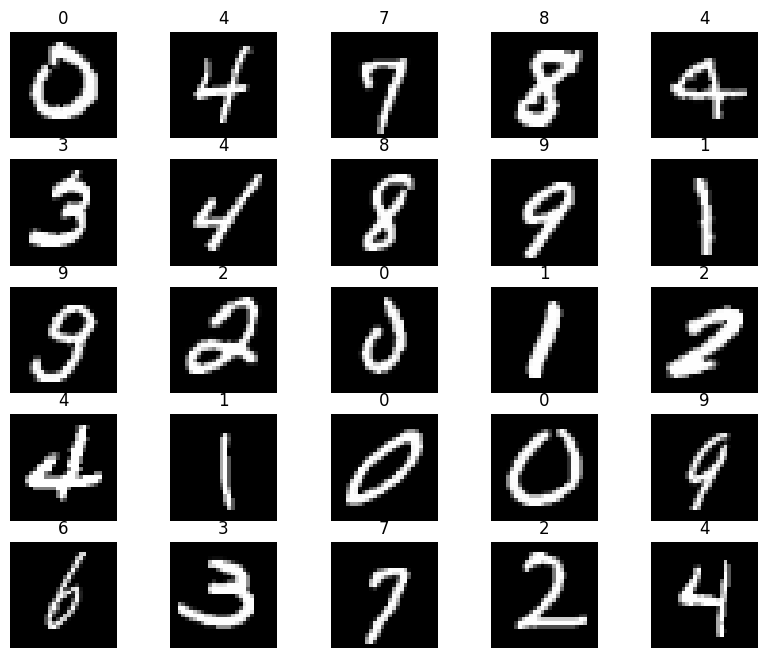

In [4]:
figure = plt.figure(figsize=(10,8))
cols, rows = 5, 5
for i in range(1, cols*rows+1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [5]:
from torch.utils.data import DataLoader # L을 대문자로 수정

loaders = {
    'train' : torch.utils.data.DataLoader( # L을 대문자로 수정
        train_data,
        batch_size=100,
        shuffle=True,
        num_workers=1
    ),
    'test' : torch.utils.data.DataLoader( # L을 대문자로 수정
        test_data,
        batch_size=100,
        shuffle=False, # 테스트 데이터는 보통 shuffle을 False로 둡니다.
        num_workers=1
    ),
}

print(loaders)

{'train': <torch.utils.data.dataloader.DataLoader object at 0x0000024CAF6B7FD0>, 'test': <torch.utils.data.dataloader.DataLoader object at 0x0000024CA86F96C0>}


In [6]:
# CNN Model (2 conv layers) 클래스 선언
class CNN(torch.nn.Module):

    def __init__(self):
        super(CNN, self).__init__()
        # 첫 번째 레이어: Conv -> ReLU -> MaxPool
        self.layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(1, 16, kernel_size=5, stride=1, padding=2), # 28x28 => 28x28 (padding 덕분)
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2))               # 28x28 => 14x14
        # 두 번째 레이어: Conv -> ReLU -> MaxPool
        self.layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2), # 14x14 => 14x14
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=2, stride=2))               # 14x14 => 7x7
        # 전결합층 (Fully Connected Layer): 7x7 크기의 32개 채널을 10개(클래스 수)로 매핑
        self.fc = torch.nn.Linear(32 * 7 * 7, 10, bias=True)       
        # 가중치 초기화 (Xavier Uniform)
        torch.nn.init.xavier_uniform_(self.fc.weight)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        # Flatten: 배치를 제외한 나머지를 한 줄로 폅니다.
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

In [7]:
model = CNN()
model

CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Linear(in_features=1568, out_features=10, bias=True)
)

In [9]:
learning_rate = 0.01
loss_func=torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [10]:
training_epochs = 10

# train my model
total_batch = len(loaders['train'])
for epoch in range(training_epochs):
    avg_cost = 0
    for X, Y in loaders['train']:
        # gradient clear before computing new gradient for the new batch
        optimizer.zero_grad()
        pred = model(X)
        cost = loss_func(pred, Y)
        cost.backward()
        optimizer.step()

        avg_cost += cost / total_batch

    print('[Epoch: {:>4}] cost = {:>.9}'.format(epoch + 1, avg_cost))

print('Learning Finished!')

[Epoch:    1] cost = 0.130665496
[Epoch:    2] cost = 0.0508491211
[Epoch:    3] cost = 0.0468785539
[Epoch:    4] cost = 0.0424280129
[Epoch:    5] cost = 0.0353673436
[Epoch:    6] cost = 0.0391442925
[Epoch:    7] cost = 0.0361076109
[Epoch:    8] cost = 0.035233181
[Epoch:    9] cost = 0.0395306051
[Epoch:   10] cost = 0.0318769254
Learning Finished!


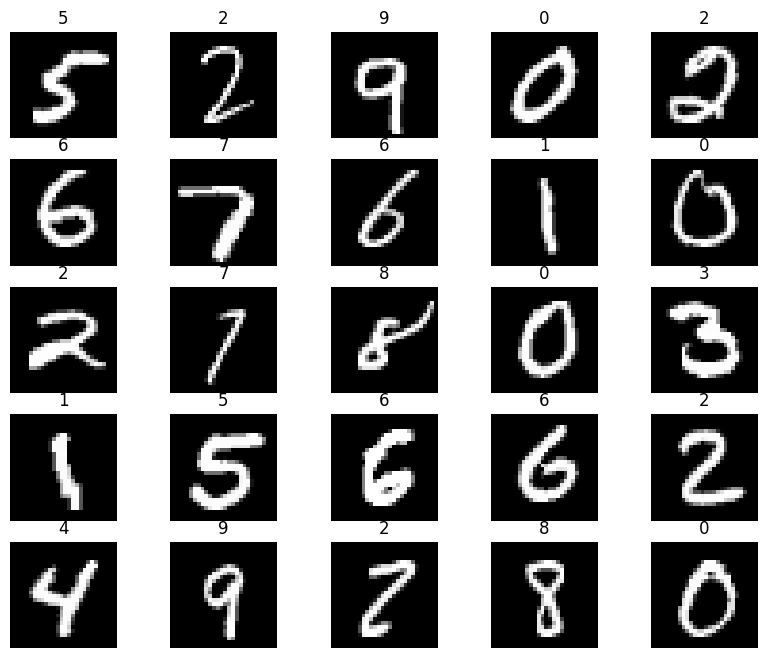

In [11]:
model.eval() # 모델을 평가 모드로 설정 (Dropout, Batch Norm 등의 동작 제어)
figure = plt.figure(figsize=(10, 8))
cols, rows = 5, 5

for i in range(1, cols * rows + 1):
    # 테스트 데이터 중 랜덤하게 하나를 선택합니다.
    sample_idx = torch.randint(len(test_data), size=(1,)).item()
    
    # 모델에 입력하기 위해 차원을 맞춥니다 (unsqueeze). 
    # [1, 28, 28] -> [1, 1, 28, 28] (배치 차원 추가)
    test_output = model(torch.unsqueeze(loaders['test'].dataset[sample_idx][0], dim=0))
    
    # 모델의 출력값 중 가장 확률이 높은 인덱스를 라벨로 선택합니다.
    label = torch.argmax(test_output)
    
    figure.add_subplot(rows, cols, i)
    plt.title(label.numpy()) # 예측된 라벨을 제목으로 표시
    plt.axis("off") # 축 표시 제거
    
    # 시각화를 위해 텐서를 넘파이 배열로 변환하고 채널 차원을 제거(squeeze)합니다.
    plt.imshow(loaders['test'].dataset[sample_idx][0].squeeze().detach().numpy(), cmap="gray")

plt.show()